#  To Bee or Not To Bee - ML Project Notebook

**IG.2412  |  Deadline: June 8th, 2026**

---

##   Project Pipeline

| Step | Description |
|------|-------------|
| 1 | Data Exploration & Loading |
| 2 | Feature Extraction (39 base features) |
| 3 | Visualization (PCA, t-SNE, UMAP, Correlation) |
| 3b | Feature Engineering (+41 derived features; 80 final features) |
| 3b | Feature Engineering (+41 derived features; 80 final features) |
| 4 | Model Training (Supervised, Ensemble, Clustering) |
| 5 | Hyperparameter Tuning (Grid Search) |
| 6 | Final Evaluation |
| 6b | Corrected Pipeline Validation + Class Imbalance Experiments |
| 6c | Model Fusion and Boosted-Tree Comparison |
| 6b | Corrected Pipeline Validation + Class Imbalance Experiments |
| 6c | Model Fusion and Boosted-Tree Comparison |
| 7 | Prediction Pipeline (Test 251-347) |


---

## Part 1: Environment Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import cv2
import os, pickle, glob, warnings
from PIL import Image
from skimage.measure import moments_hu

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, train_test_split, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, silhouette_score, adjusted_rand_score

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
import umap

warnings.filterwarnings("ignore")
print("  All imports successful!")


  All imports successful!


---

## Part 2: Data Loading & Exploration

### 2.1 Path Configuration

In [2]:
WORK_DIR = os.getcwd()
BASE_DIR = os.path.join(WORK_DIR, "train")
MASKS_DIR = os.path.join(BASE_DIR, "masks")
CLASSIF_PATH = os.path.join(BASE_DIR, "classif.xlsx")
FEATURES_PATH = os.path.join(WORK_DIR, "features.csv")
SCALE = 0.2

print(f"Work Directory:   {WORK_DIR}")
print(f"Train Directory:  {BASE_DIR}")
print(f"Masks Directory:  {MASKS_DIR}")
print(f"Classification:   {CLASSIF_PATH}")
print(f"Image scale:      {SCALE*100:.0f}%")

Work Directory:   c:\Users\13968\Documents\ML机器学习
Train Directory:  c:\Users\13968\Documents\ML机器学习\train
Masks Directory:  c:\Users\13968\Documents\ML机器学习\train\masks
Classification:   c:\Users\13968\Documents\ML机器学习\train\classif.xlsx
Image scale:      20%


### 2.2 Load Labels

In [ ]:
if os.path.exists(CLASSIF_PATH):
    classif_df = pd.read_excel(CLASSIF_PATH)
    print(f"Loaded labels from: {CLASSIF_PATH}")
elif os.path.exists(FEATURES_PATH):
    classif_df = pd.read_csv(FEATURES_PATH)[["ID", "bug type", "species"]].copy()
    print(f"train/classif.xlsx not found; rebuilt labels from: {FEATURES_PATH}")
else:
    raise FileNotFoundError(
        "Neither train/classif.xlsx nor features.csv was found. "
        "Provide the training data or the extracted features table."
    )

print(f"Total samples: {len(classif_df)}")
print(f"\nColumns: {list(classif_df.columns)}")
print(f"\n--- Bug Type Distribution ---")
print(classif_df["bug type"].value_counts())
print(f"\n--- Species (Top 15) ---")
print(classif_df["species"].value_counts().head(15))


### 2.3 Distribution Plots

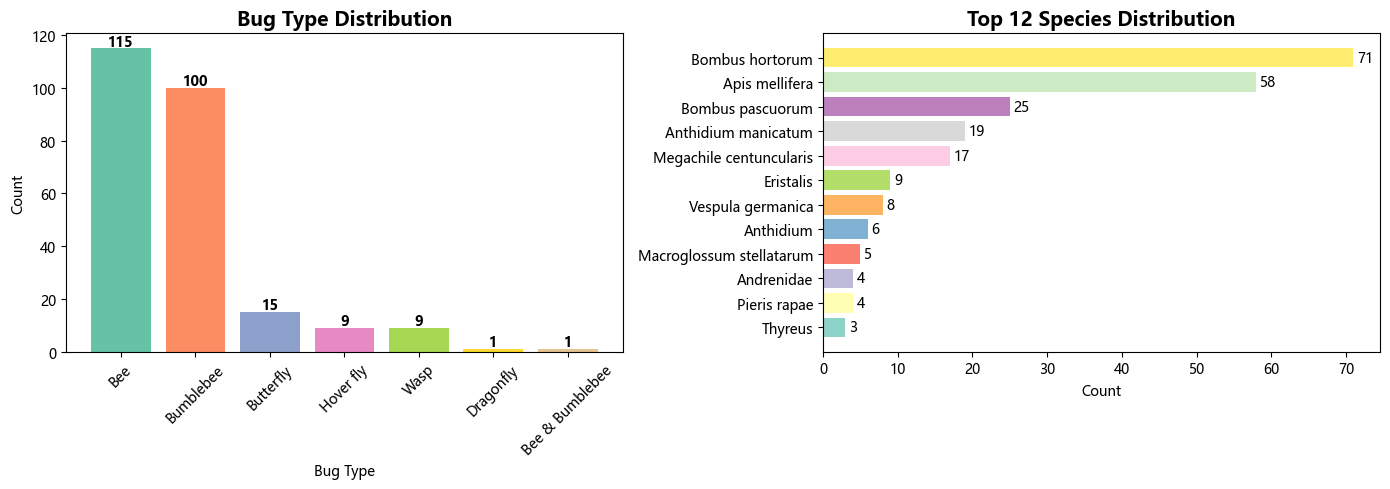

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
type_counts = classif_df["bug type"].value_counts()
colors = sns.color_palette("Set2", len(type_counts))
axes[0].bar(type_counts.index, type_counts.values, color=colors)
axes[0].set_title("Bug Type Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Bug Type"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 1, str(v), ha="center", fontweight="bold")

species_counts = classif_df["species"].value_counts().head(12)
axes[1].barh(species_counts.index[::-1], species_counts.values[::-1], color=sns.color_palette("Set3", 12))
axes[1].set_title("Top 12 Species Distribution", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Count")
for i, v in enumerate(species_counts.values[::-1]):
    axes[1].text(v + 0.5, i, str(v), va="center")

plt.tight_layout(); plt.show()

### 2.4 Sample Images with Masks

In [ ]:
sample_ids = [1, 50, 100, 150, 200, 250]
available_ids = [
    img_id for img_id in sample_ids
    if os.path.exists(os.path.join(BASE_DIR, f"{img_id}.JPG"))
]

if not available_ids:
    print("Training images are not available in this workspace; skipping sample image display.")
else:
    fig, axes = plt.subplots(2, len(available_ids), figsize=(3 * len(available_ids), 6))
    if len(available_ids) == 1:
        axes = np.array(axes).reshape(2, 1)

    for i, img_id in enumerate(available_ids):
        img_pil = Image.open(os.path.join(BASE_DIR, f"{img_id}.JPG"))
        w, h = img_pil.size
        img_pil = img_pil.resize((int(w*SCALE), int(h*SCALE)), Image.LANCZOS)
        img_rgb = np.array(img_pil)
        axes[0, i].imshow(img_rgb)
        axes[0, i].set_title(f"ID: {img_id}", fontsize=9)
        axes[0, i].axis("off")

        mask_path = os.path.join(MASKS_DIR, f"binary_{img_id}.tif")
        if os.path.exists(mask_path):
            mask_pil = Image.open(mask_path)
            mask_pil = mask_pil.resize((int(w*SCALE), int(h*SCALE)), Image.NEAREST)
            mask = np.array(mask_pil)
            if mask.ndim == 3:
                mask = mask[:, :, 0] > 0
            else:
                mask = mask > 0
            overlay = img_rgb.copy()
            overlay[mask] = overlay[mask] * 0.6 + np.array([0, 255, 0]) * 0.4
            axes[1, i].imshow(overlay)
        else:
            axes[1, i].imshow(img_rgb)
        axes[1, i].set_title(f"Mask {img_id}", fontsize=9)
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontweight="bold")
    axes[1, 0].set_ylabel("+ Mask", fontweight="bold")
    plt.tight_layout()
    plt.show()


---

## Part 3: Feature Extraction

### 3.1 Feature Functions

Features extracted (33 dimensions):
- **Symmetry (3):** sym_h, sym_v, sym_aspect
- **Hu Moments (7):** hu1 - hu7
- **Shape Geometric (7):** solidity, eccentricity, extent, perimeter, area, convex_area, compactness
- **Color RGB (15):** r/g/b min, max, mean, median, std
- **Custom (7):** pixel_ratio, bg_brightness, color_dominance, edge_density, texture_contrast, brightness_mean, saturation_mean


In [6]:
def load_image_and_mask(img_id, base_dir=BASE_DIR, masks_dir=MASKS_DIR):
    img_path = os.path.join(base_dir, f'{img_id}.JPG')
    mask_path = os.path.join(masks_dir, f'binary_{img_id}.tif')
    img_pil = Image.open(img_path)
    w, h = img_pil.size
    new_size = (int(w * SCALE), int(h * SCALE))
    img_pil = img_pil.resize(new_size, Image.LANCZOS)
    img_rgb = np.array(img_pil)
    mask = None
    if os.path.exists(mask_path):
        mask_pil = Image.open(mask_path)
        mask_pil = mask_pil.resize(new_size, Image.NEAREST)
        mask_full = np.array(mask_pil)
        if mask_full.ndim == 3:
            mask = (mask_full[:,:,0] > 0).astype(np.uint8)
        else:
            mask = (mask_full > 0).astype(np.uint8)
    return img_rgb, mask

def compute_symmetry_features(mask):
    if mask is None or mask.sum() == 0:
        return {'sym_h': 0, 'sym_v': 0, 'sym_aspect': 0}
    h, w = mask.shape
    left = mask[:, :w//2]
    right_flipped = np.fliplr(mask[:, w//2:])
    min_w = min(left.shape[1], right_flipped.shape[1])
    left, right_flipped = left[:, :min_w], right_flipped[:, :min_w]
    inter_h = np.logical_and(left, right_flipped).sum()
    union_h = np.logical_or(left, right_flipped).sum()
    sym_h = inter_h / union_h if union_h > 0 else 0
    top = mask[:h//2, :]
    bottom_flipped = np.flipud(mask[h//2:, :])
    min_h = min(top.shape[0], bottom_flipped.shape[0])
    top, bottom_flipped = top[:min_h, :], bottom_flipped[:min_h, :]
    inter_v = np.logical_and(top, bottom_flipped).sum()
    union_v = np.logical_or(top, bottom_flipped).sum()
    sym_v = inter_v / union_v if union_v > 0 else 0
    rows = np.any(mask, axis=1); cols = np.any(mask, axis=0)
    if rows.sum() and cols.sum():
        ymin, ymax = np.where(rows)[0][[0, -1]]
        xmin, xmax = np.where(cols)[0][[0, -1]]
        sym_aspect = (ymax - ymin + 1) / (xmax - xmin + 1)
    else:
        sym_aspect = 0
    return {'sym_h': round(sym_h, 6), 'sym_v': round(sym_v, 6), 'sym_aspect': round(sym_aspect, 6)}

def compute_shape_features(mask):
    zero = {f'hu{i}': 0 for i in range(1, 8)}
    zero.update({'solidity': 0, 'eccentricity': 0, 'extent': 0, 'perimeter': 0, 'area': 0, 'convex_area': 0, 'compactness': 0})
    if mask is None or mask.sum() == 0:
        return zero
    mask_u8 = mask.astype(np.uint8)
    hu = moments_hu(mask_u8.astype(float))
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return zero
    c = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(c)
    perimeter = cv2.arcLength(c, True)
    hull = cv2.convexHull(c)
    convex_area = cv2.contourArea(hull)
    solidity = area / convex_area if convex_area > 0 else 0
    compactness = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
    if len(c) >= 5:
        (_, _), (major, minor), _ = cv2.fitEllipse(c)
        mx, mn = max(major, minor), min(major, minor)
        eccentricity = np.sqrt(1 - (mn / mx) ** 2) if mx > 0 else 0
    else:
        eccentricity = 0
    x, y, bw, bh = cv2.boundingRect(c)
    extent = area / (bw * bh) if bw * bh > 0 else 0
    result = {f'hu{i}': round(hu_log[i-1], 6) for i in range(1, 8)}
    result.update({'solidity': round(solidity, 6), 'eccentricity': round(eccentricity, 6), 'extent': round(extent, 6), 'perimeter': round(perimeter, 2), 'area': round(area, 2), 'convex_area': round(convex_area, 2), 'compactness': round(compactness, 6)})
    return result

def compute_color_features(img_rgb, mask):
    zero = {}
    for ch in ['r', 'g', 'b']:
        for stat in ['min', 'max', 'mean', 'median', 'std']:
            zero[f'{ch}_{stat}'] = 0
    if mask is None or mask.sum() == 0:
        return zero
    features = {}
    for i, name in enumerate(['r', 'g', 'b']):
        channel = img_rgb[:, :, i][mask > 0]
        if len(channel) == 0:
            return zero
        features[f'{name}_min'] = float(channel.min())
        features[f'{name}_max'] = float(channel.max())
        features[f'{name}_mean'] = round(float(channel.mean()), 4)
        features[f'{name}_median'] = round(float(np.median(channel)), 4)
        features[f'{name}_std'] = round(float(channel.std()), 4)
    return features

def compute_pixel_ratio(mask):
    if mask is None or mask.sum() == 0:
        return 0.0
    return round(mask.sum() / mask.size, 6)

def compute_custom_features(img_rgb, mask):
    default = {'bg_brightness': 0, 'color_dominance': 0, 'edge_density': 0, 'texture_contrast': 0, 'brightness_mean': 0, 'saturation_mean': 0}
    if mask is None or mask.sum() == 0:
        return default
    outside = (mask == 0); inside = (mask > 0)
    bg_pixels = img_rgb[outside]
    bg_brightness = float(np.mean(bg_pixels)) if len(bg_pixels) > 0 else 0
    r_mean = img_rgb[:,:,0][inside].mean()
    g_mean = img_rgb[:,:,1][inside].mean()
    b_mean = img_rgb[:,:,2][inside].mean()
    total = r_mean + g_mean + b_mean
    color_dominance = round(max(r_mean, g_mean, b_mean) / total, 6) if total > 0 else 0
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    gray_copy = gray.copy(); gray_copy[mask == 0] = 0
    edges = cv2.Canny(gray_copy.astype(np.uint8), 50, 150)
    mask_pixels = mask.sum()
    edge_density = round((edges > 0).sum() / mask_pixels, 6) if mask_pixels > 0 else 0
    texture_contrast = round(float(gray[inside].std()), 4) if mask_pixels > 0 else 0
    brightness_mean = round(float(np.mean(img_rgb[inside])), 4) if mask_pixels > 0 else 0
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    saturation_mean = round(float(hsv[:,:,1][inside].mean()), 4) if mask_pixels > 0 else 0
    return {'bg_brightness': round(bg_brightness, 4), 'color_dominance': color_dominance, 'edge_density': edge_density, 'texture_contrast': texture_contrast, 'brightness_mean': brightness_mean, 'saturation_mean': saturation_mean}

def extract_features_for_image(img_id, img_rgb, mask):
    features = {'ID': img_id}
    features.update(compute_symmetry_features(mask))
    features.update(compute_shape_features(mask))
    features.update(compute_color_features(img_rgb, mask))
    features['pixel_ratio'] = compute_pixel_ratio(mask)
    features.update(compute_custom_features(img_rgb, mask))
    return features

dummy_img = np.zeros((10, 10, 3), dtype=np.uint8)
dummy_mask = np.zeros((10, 10), dtype=np.uint8)
n_features = len(extract_features_for_image(0, dummy_img, dummy_mask)) - 1
print(f'Feature functions defined! Features per image: {n_features}')

Feature functions defined! Features per image: 39


### 3.2 Run Feature Extraction

In [7]:
if os.path.exists(FEATURES_PATH):
    print("  Loading existing features.csv...")
    df = pd.read_csv(FEATURES_PATH)
    print(f"  Loaded {len(df)} samples, {len(df.columns)-3} features")
else:
    print("Extracting features (this may take a while)...")
    all_features = []
    for idx, row in classif_df.iterrows():
        img_id = row["ID"]
        try:
            img_rgb, mask = load_image_and_mask(img_id)
            features = extract_features_for_image(img_id, img_rgb, mask)
            all_features.append(features)
            if img_id % 25 == 0 or img_id == 1:
                print(f"  Progress: {img_id}/250")
        except Exception as e:
            print(f"  Error on {img_id}: {e}")
    features_df = pd.DataFrame(all_features)
    df = classif_df.merge(features_df, on="ID", how="left")
    df.to_csv(FEATURES_PATH, index=False)
    print(f"\n  Feature extraction complete!")

feature_cols = [c for c in df.columns if c not in ["ID", "bug type", "species"]]
print(f"\nFeatures: {len(feature_cols)}")
df.head()

  Loading existing features.csv...
  Loaded 250 samples, 39 features

Features: 39


,ID,bug type,species,sym_h,sym_v,sym_aspect,hu1,hu2,hu3,hu4,...,b_mean,b_median,b_std,pixel_ratio,bg_brightness,color_dominance,edge_density,texture_contrast,brightness_mean,saturation_mean
0,1,Bee,Apis mellifera,0.490364,0.019925,0.824427,0.0,0.0,0.0,0.0,...,39.8132,24.0,35.7833,0.007411,99.1187,0.418157,0.272804,44.4720,54.2107,112.9330
1,2,Bee,Apis mellifera,0.412442,0.000000,0.662722,0.0,0.0,0.0,0.0,...,35.7727,19.0,34.4776,0.008561,91.5545,0.420680,0.253680,41.2834,50.5900,123.7198
2,3,Bee,Apis mellifera,0.115530,0.000000,0.941964,0.0,0.0,0.0,0.0,...,63.4173,52.0,54.5554,0.022088,114.9329,0.414797,0.234437,58.1445,86.1339,124.4050
3,4,Bee,Apis mellifera,0.002698,0.052557,0.774359,0.0,0.0,0.0,0.0,...,50.2936,37.0,37.2071,0.013164,105.4972,0.419211,0.233600,44.5780,69.5575,118.6115
4,5,Bee,Apis mellifera,0.224641,0.099461,0.834356,0.0,0.0,0.0,0.0,...,80.8283,63.0,60.3444,0.009143,111.0150,0.403956,0.273556,61.6640,101.5431,102.0434


---

## Part 4: Data Visualization

### 4.1 Prepare Data

In [8]:
rare_mask = df["bug type"].isin(["Bee & Bumblebee", "Dragonfly"])
df_filtered = df[~rare_mask].copy()
print(f"Removed {rare_mask.sum()} rare-class samples")
print(f"\nFiltered class distribution:")
print(df_filtered["bug type"].value_counts())

feature_cols = [c for c in df.columns if c not in ["ID", "bug type", "species"]]
X = df_filtered[feature_cols].values.astype(np.float64)
y = df_filtered["bug type"].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\nClasses: {list(le.classes_)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\nShape: {X_scaled.shape}, mean={X_scaled.mean():.6f}, std={X_scaled.std():.6f}")

Removed 2 rare-class samples

Filtered class distribution:
bug type
Bee          115
Bumblebee    100
Butterfly     15
Hover fly      9
Wasp           9
Name: count, dtype: int64

Classes: ['Bee', 'Bumblebee', 'Butterfly', 'Hover fly', 'Wasp']

Shape: (248, 39), mean=-0.000000, std=0.987096


### 4.2 PCA Projection

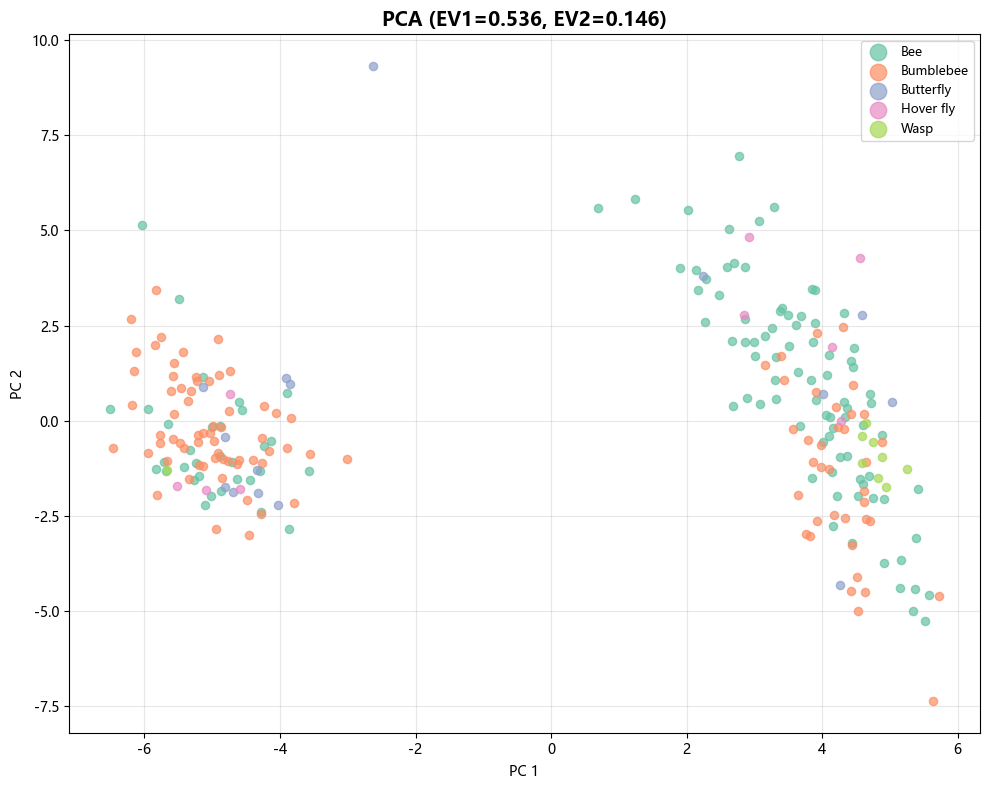

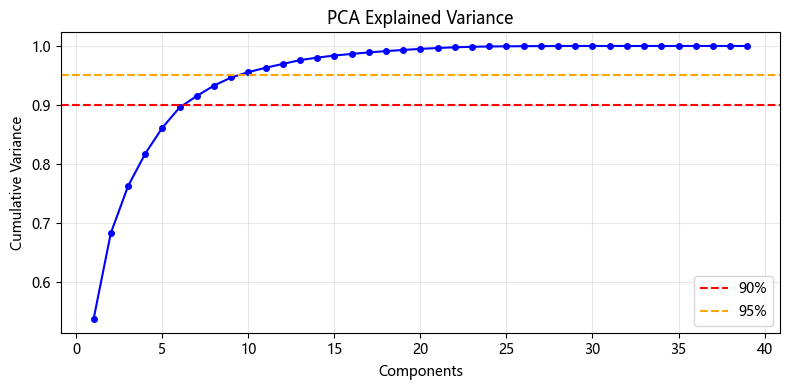

Components for 90%: 7, for 95%: 10


In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
palette = sns.color_palette("Set2", len(le.classes_))
for i, label in enumerate(le.classes_):
    mask = y == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=label, alpha=0.7, s=35, color=palette[i])
ax.set_title(f"PCA (EV1={pca.explained_variance_ratio_[0]:.3f}, EV2={pca.explained_variance_ratio_[1]:.3f})", fontsize=14, fontweight="bold")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.legend(markerscale=2, fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

pca_full = PCA().fit(X_scaled)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumsum)+1), cumsum, "b-o", markersize=4)
ax.axhline(y=0.9, color="r", linestyle="--", label="90%")
ax.axhline(y=0.95, color="orange", linestyle="--", label="95%")
ax.set_xlabel("Components"); ax.set_ylabel("Cumulative Variance")
ax.set_title("PCA Explained Variance"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

n_90 = np.argmax(cumsum >= 0.9) + 1
n_95 = np.argmax(cumsum >= 0.95) + 1
print(f"Components for 90%: {n_90}, for 95%: {n_95}")

### 4.3 t-SNE Projection

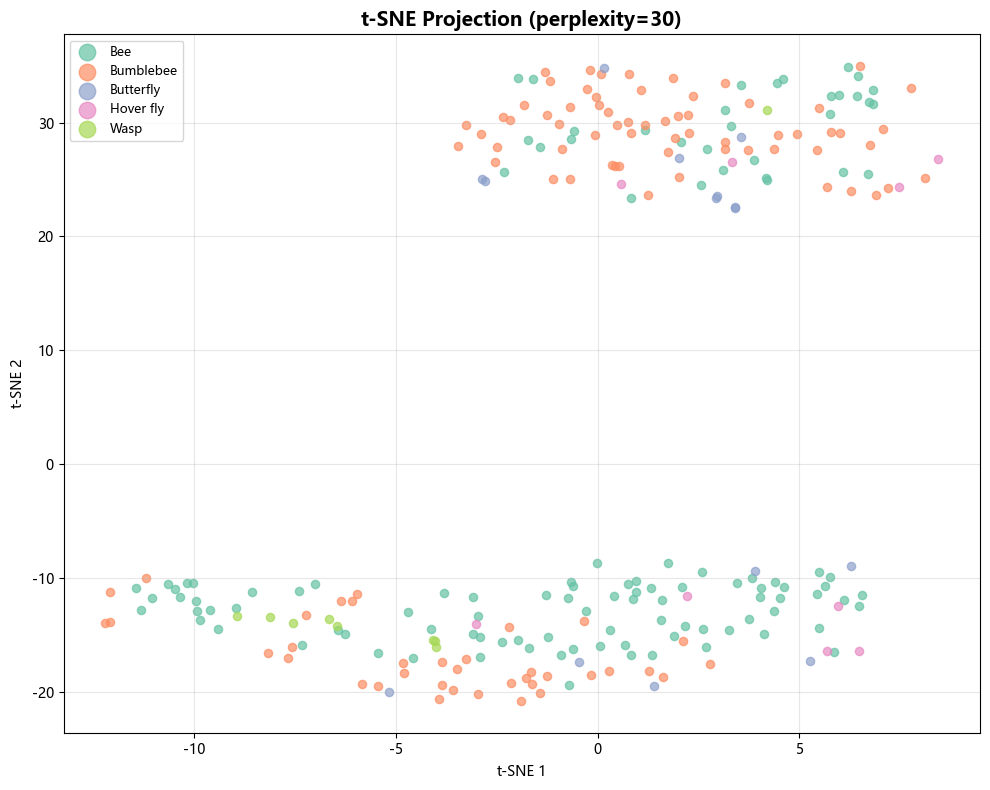

In [10]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
for i, label in enumerate(le.classes_):
    mask = y == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=label, alpha=0.7, s=35, color=palette[i])
ax.set_title("t-SNE Projection (perplexity=30)", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=2, fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 4.4 UMAP Projection

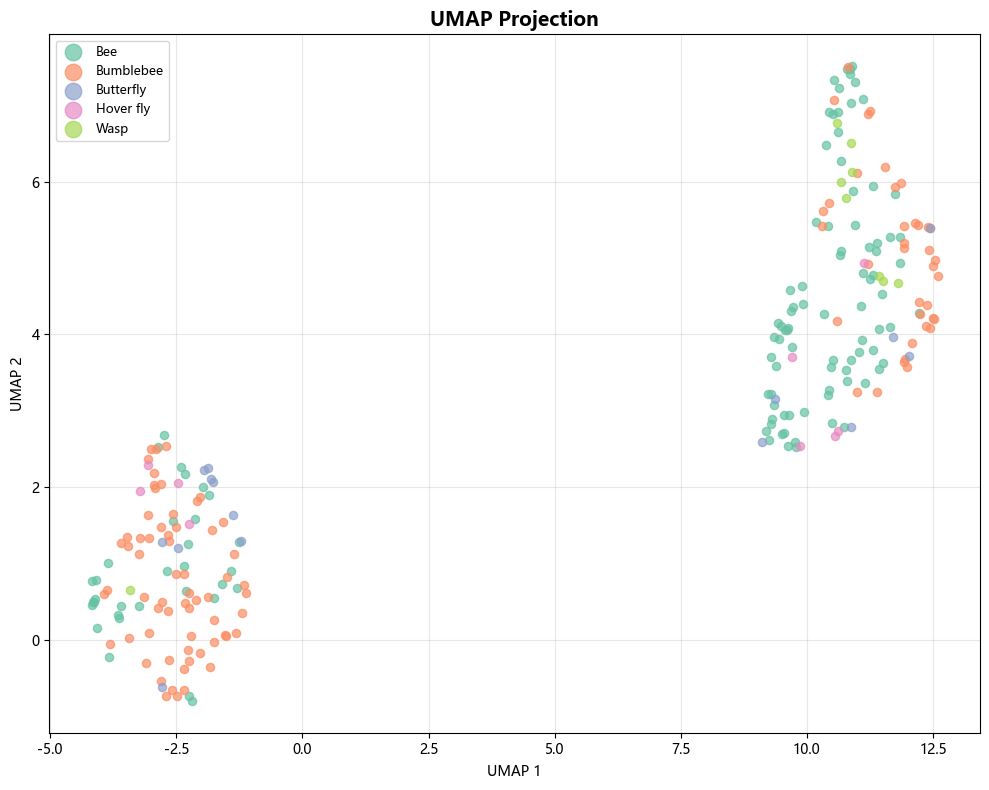

In [11]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
for i, label in enumerate(le.classes_):
    mask = y == label
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1], label=label, alpha=0.7, s=35, color=palette[i])
ax.set_title("UMAP Projection", fontsize=14, fontweight="bold")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.legend(markerscale=2, fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 4.5 Correlation Heatmap

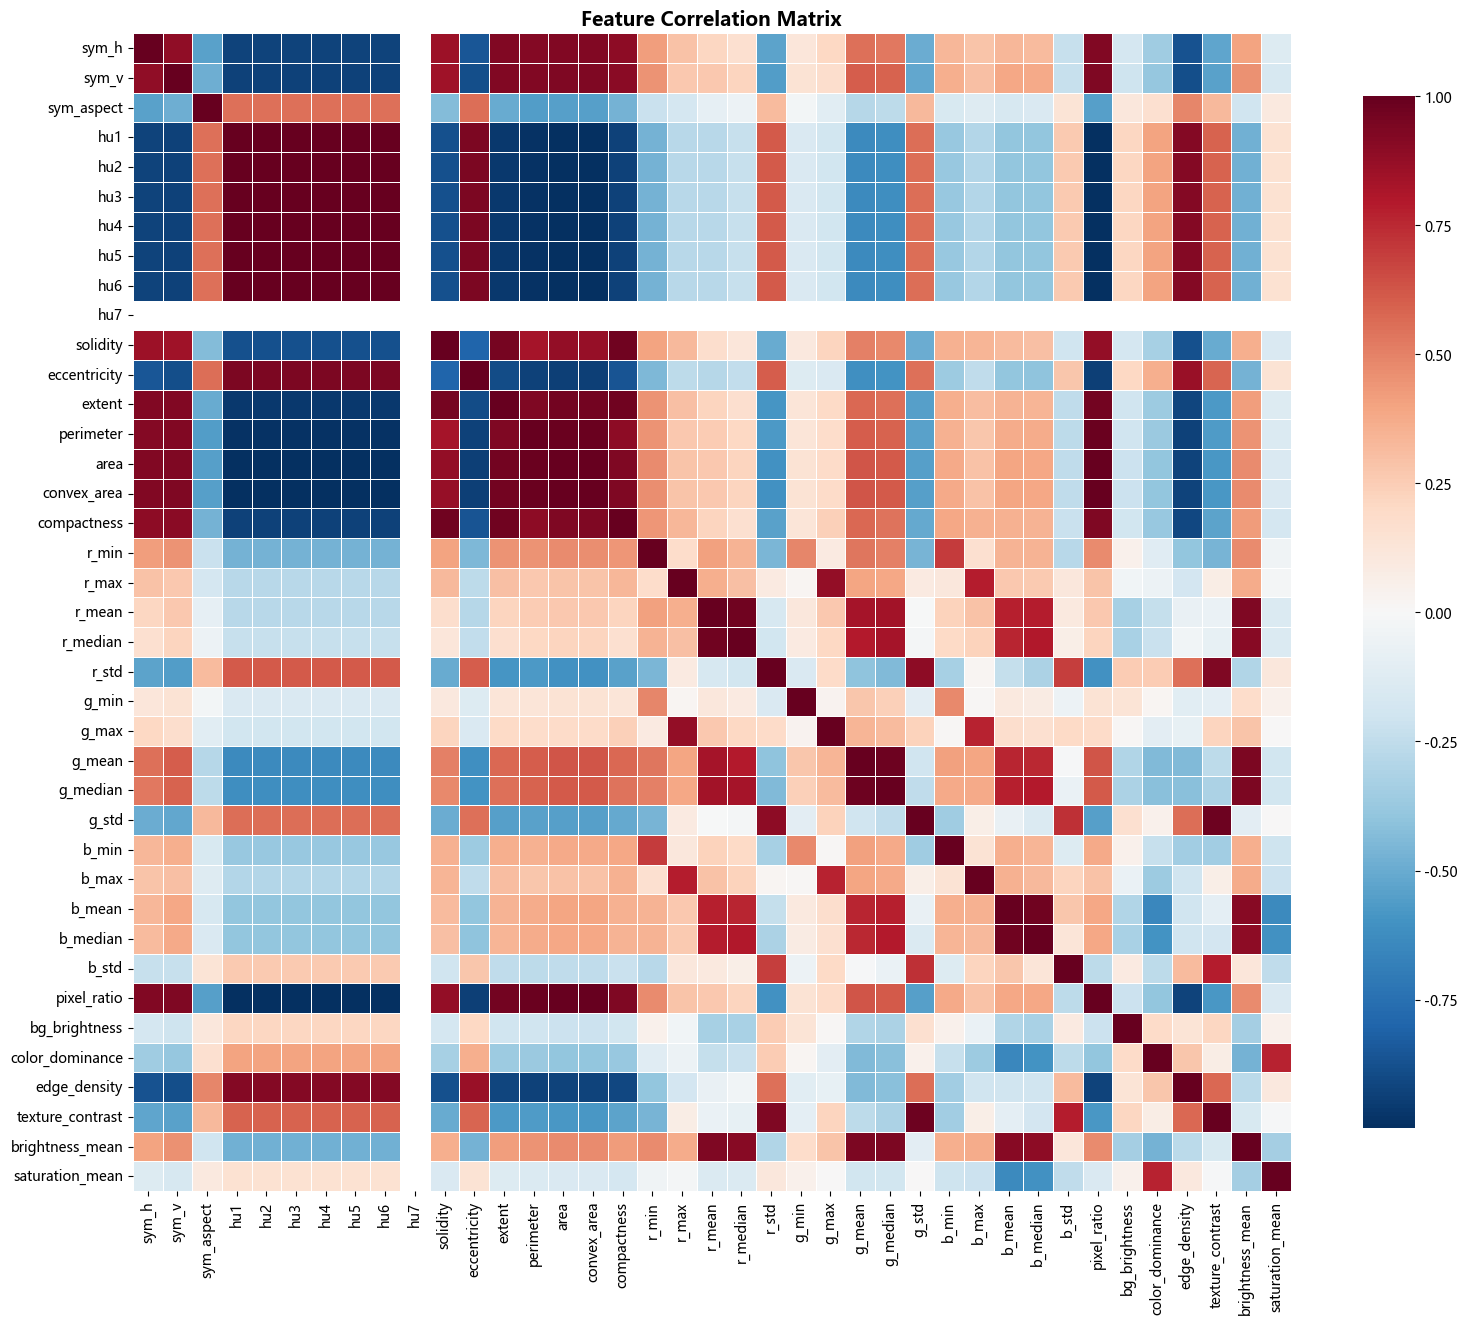

Highly correlated pairs (|r| > 0.9):
  sym_h <-> hu1: r=-0.924
  sym_h <-> hu2: r=-0.924
  sym_h <-> hu3: r=-0.924
  sym_h <-> hu4: r=-0.924
  sym_h <-> hu5: r=-0.924
  sym_h <-> hu6: r=-0.924
  sym_h <-> extent: r=0.924
  sym_h <-> perimeter: r=0.916
  sym_h <-> area: r=0.926
  sym_h <-> convex_area: r=0.926
  sym_h <-> pixel_ratio: r=0.927
  sym_v <-> hu1: r=-0.935
  sym_v <-> hu2: r=-0.935
  sym_v <-> hu3: r=-0.935
  sym_v <-> hu4: r=-0.935
  sym_v <-> hu5: r=-0.935
  sym_v <-> hu6: r=-0.935
  sym_v <-> extent: r=0.923
  sym_v <-> perimeter: r=0.927
  sym_v <-> area: r=0.937
  sym_v <-> convex_area: r=0.937
  sym_v <-> pixel_ratio: r=0.937
  hu1 <-> hu2: r=1.000
  hu1 <-> hu3: r=1.000
  hu1 <-> hu4: r=1.000
  hu1 <-> hu5: r=1.000
  hu1 <-> hu6: r=1.000
  hu1 <-> eccentricity: r=0.943
  hu1 <-> extent: r=-0.963
  hu1 <-> perimeter: r=-0.986
  hu1 <-> area: r=-1.000
  hu1 <-> convex_area: r=-0.999
  hu1 <-> compactness: r=-0.930
  hu1 <-> pixel_ratio: r=-0.999
  hu1 <-> edge_density: 

In [12]:
corr = df_filtered[feature_cols].corr()
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

print("Highly correlated pairs (|r| > 0.9):")
found = False
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        if abs(corr.iloc[i, j]) > 0.9:
            print(f"  {feature_cols[i]} <-> {feature_cols[j]}: r={corr.iloc[i, j]:.3f}")
            found = True
if not found:
    print("  None found")

---

## Part 5: Initial Model Training

### 5.0 Cross-Validation Setup

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('CV: 5-fold StratifiedKFold')

CV: 5-fold StratifiedKFold


### 5.1 Logistic Regression

In [14]:
print("=" * 50)
print("Logistic Regression")
print("=" * 50)
lr = LogisticRegression(max_iter=2000, random_state=42)
lr_scores = cross_val_score(lr, X_scaled, y_encoded, cv=cv, scoring="accuracy")
print(f"5-fold CV: {lr_scores.mean():.4f} +/- {lr_scores.std():.4f}")
print(f"Per-fold: {[round(s, 4) for s in lr_scores]}")

Logistic Regression
5-fold CV: 0.7094 +/- 0.0504
Per-fold: [np.float64(0.74), np.float64(0.78), np.float64(0.68), np.float64(0.7143), np.float64(0.6327)]


### 5.2 K-Nearest Neighbors

In [15]:
print("=" * 50)
print("KNN (k=5)")
print("=" * 50)
knn = KNeighborsClassifier(n_neighbors=5)
knn_scores = cross_val_score(knn, X_scaled, y_encoded, cv=cv, scoring="accuracy")
print(f"5-fold CV: {knn_scores.mean():.4f} +/- {knn_scores.std():.4f}")
print(f"Per-fold: {[round(s, 4) for s in knn_scores]}")

KNN (k=5)
5-fold CV: 0.7220 +/- 0.0449
Per-fold: [np.float64(0.74), np.float64(0.72), np.float64(0.64), np.float64(0.7755), np.float64(0.7347)]


### 5.3 SVM (RBF Kernel)

In [16]:
print("=" * 50)
print("SVM (RBF)")
print("=" * 50)
svm = SVC(kernel="rbf", random_state=42)
svm_scores = cross_val_score(svm, X_scaled, y_encoded, cv=cv, scoring="accuracy")
print(f"5-fold CV: {svm_scores.mean():.4f} +/- {svm_scores.std():.4f}")
print(f"Per-fold: {[round(s, 4) for s in svm_scores]}")

SVM (RBF)
5-fold CV: 0.7178 +/- 0.0415
Per-fold: [np.float64(0.76), np.float64(0.74), np.float64(0.64), np.float64(0.7347), np.float64(0.7143)]


### 5.4 Random Forest (Ensemble)

In [17]:
print("=" * 50)
print("Random Forest")
print("=" * 50)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_scores = cross_val_score(rf, X_scaled, y_encoded, cv=cv, scoring="accuracy")
print(f"5-fold CV: {rf_scores.mean():.4f} +/- {rf_scores.std():.4f}")
print(f"Per-fold: {[round(s, 4) for s in rf_scores]}")

Random Forest
5-fold CV: 0.7253 +/- 0.0654
Per-fold: [np.float64(0.8), np.float64(0.8), np.float64(0.7), np.float64(0.6327), np.float64(0.6939)]


### 5.5 KMeans Clustering

In [18]:
print("=" * 50)
print("KMeans Clustering")
print("=" * 50)
n_clusters = len(np.unique(y_encoded))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
sil_km = silhouette_score(X_scaled, kmeans_labels)
ari_km = adjusted_rand_score(y_encoded, kmeans_labels)
print(f"Clusters: {n_clusters}")
print(f"Silhouette: {sil_km:.4f}, ARI: {ari_km:.4f}")

KMeans Clustering
Clusters: 5
Silhouette: 0.1876, ARI: 0.0808


### 5.6 DBSCAN Clustering

In [19]:
print("=" * 50)
print("DBSCAN Clustering")
print("=" * 50)
dbscan = DBSCAN(eps=2.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
print(f"Clusters: {n_clusters_db}, Noise: {n_noise}")
if n_clusters_db > 1:
    valid = dbscan_labels != -1
    if valid.sum() > 1 and len(set(dbscan_labels[valid])) > 1:
        sil_db = silhouette_score(X_scaled[valid], dbscan_labels[valid])
        ari_db = adjusted_rand_score(y_encoded[valid], dbscan_labels[valid])
        print(f"Silhouette: {sil_db:.4f}, ARI: {ari_db:.4f}")

DBSCAN Clustering
Clusters: 2, Noise: 144
Silhouette: 0.6111, ARI: 0.0814


### 5.7 LDA (Bonus)

In [20]:
print("=" * 50)
print("LDA")
print("=" * 50)
lda = LinearDiscriminantAnalysis()
lda_scores = cross_val_score(lda, X_scaled, y_encoded, cv=cv, scoring="accuracy")
print(f"5-fold CV: {lda_scores.mean():.4f} +/- {lda_scores.std():.4f}")

LDA
5-fold CV: 0.7420 +/- 0.0391


### 5.8 Initial Results Summary

In [21]:
initial_results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN (k=5)", "SVM (RBF)", "Random Forest",
              "KMeans", "DBSCAN", "LDA"],
    "Score": [
        f"{lr_scores.mean():.4f}+/-{lr_scores.std():.4f}",
        f"{knn_scores.mean():.4f}+/-{knn_scores.std():.4f}",
        f"{svm_scores.mean():.4f}+/-{svm_scores.std():.4f}",
        f"{rf_scores.mean():.4f}+/-{rf_scores.std():.4f}",
        f"Sil={sil_km:.4f}|ARI={ari_km:.4f}",
        f"Sil={sil_db:.4f}|ARI={ari_db:.4f}" if n_clusters_db > 1 else "N/A",
        f"{lda_scores.mean():.4f}+/-{lda_scores.std():.4f}",
    ]
})
print("\nINITIAL MODEL RESULTS")
print("=" * 60)
print(initial_results.to_string(index=False))
initial_results.to_csv(os.path.join(WORK_DIR, "model_results.csv"), index=False)


INITIAL MODEL RESULTS
              Model                 Score
Logistic Regression       0.7094+/-0.0504
          KNN (k=5)       0.7220+/-0.0449
          SVM (RBF)       0.7178+/-0.0415
      Random Forest       0.7253+/-0.0654
             KMeans Sil=0.1876|ARI=0.0808
             DBSCAN Sil=0.6111|ARI=0.0814
                LDA       0.7420+/-0.0391


---

## Part 6: Hyperparameter Tuning

### 6.1 Random Forest Grid Search

In [22]:
print("Random Forest Grid Search...")
rf_params = {"n_estimators": [100, 200, 300], "max_depth": [5, 10, 15, None],
             "min_samples_split": [2, 5], "class_weight": ["balanced", "balanced_subsample", None]}
rf_gs = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring="accuracy", n_jobs=-1, verbose=1)
rf_gs.fit(X_scaled, y_encoded)
print(f"\nBest: {rf_gs.best_params_}")
print(f"Score: {rf_gs.best_score_:.4f}")

Random Forest Grid Search...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Best: {'class_weight': None, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Score: 0.6367


### 6.2 SVM Grid Search

In [23]:
print("SVM Grid Search...")
svm_params = {"C": [0.1, 1, 10], "gamma": ["scale", "auto", 0.1, 0.01], "class_weight": ["balanced", None]}
svm_gs = GridSearchCV(SVC(kernel="rbf", random_state=42), svm_params, cv=3, scoring="accuracy", n_jobs=-1, verbose=1)
svm_gs.fit(X_scaled, y_encoded)
print(f"\nBest: {svm_gs.best_params_}")
print(f"Score: {svm_gs.best_score_:.4f}")

SVM Grid Search...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best: {'C': 10, 'class_weight': None, 'gamma': 'scale'}
Score: 0.6648


### 6.3 KNN Grid Search

In [24]:
print("KNN Grid Search...")
knn_params = {"n_neighbors": [3, 5, 7, 9, 11], "weights": ["uniform", "distance"]}
knn_gs = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3, scoring="accuracy", verbose=1)
knn_gs.fit(X_scaled, y_encoded)
print(f"\nBest: {knn_gs.best_params_}")
print(f"Score: {knn_gs.best_score_:.4f}")

KNN Grid Search...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best: {'n_neighbors': 5, 'weights': 'distance'}
Score: 0.6088


---

## Part 7: Final Evaluation

### 7.1 Train/Test Split Evaluation

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

models = {
    "Logistic Regression (balanced)": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "KNN (best)": knn_gs.best_estimator_,
    "SVM (best)": svm_gs.best_estimator_,
    "Random Forest (best)": rf_gs.best_estimator_,
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "LDA": LinearDiscriminantAnalysis()
}

final_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y_encoded, cv=cv, scoring="accuracy")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    final_results.append({"Model": name, "CV Mean": scores.mean(), "CV Std": scores.std(), "Test Acc": acc})
    print(f"--- {name} ---")
    print(f"CV: {scores.mean():.4f} +/- {scores.std():.4f}")
    print(f"Test: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))
    print()

final_df = pd.DataFrame(final_results)
print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(final_df.round(4).to_string(index=False))
final_df.to_csv(os.path.join(WORK_DIR, "final_results.csv"), index=False)

best_idx = final_df["Test Acc"].idxmax()
best_name = final_df.loc[best_idx, "Model"]
print(f"\n  Best: {best_name} (Test Acc: {final_df.loc[best_idx, 'Test Acc']:.4f})")

Train: 198, Test: 50
--- Logistic Regression (balanced) ---
CV: 0.6407 +/- 0.0725
Test: 0.6800
              precision    recall  f1-score   support

         Bee       0.81      0.57      0.67        23
   Bumblebee       0.84      0.80      0.82        20
   Butterfly       0.60      1.00      0.75         3
   Hover fly       0.17      0.50      0.25         2
        Wasp       0.25      0.50      0.33         2

    accuracy                           0.68        50
   macro avg       0.53      0.67      0.56        50
weighted avg       0.76      0.68      0.70        50


--- KNN (best) ---
CV: 0.7382 +/- 0.0524
Test: 0.6000
              precision    recall  f1-score   support

         Bee       0.63      0.74      0.68        23
   Bumblebee       0.60      0.60      0.60        20
   Butterfly       0.00      0.00      0.00         3
   Hover fly       0.00      0.00      0.00         2
        Wasp       0.50      0.50      0.50         2

    accuracy                       

### 7.2 Model Comparison Chart

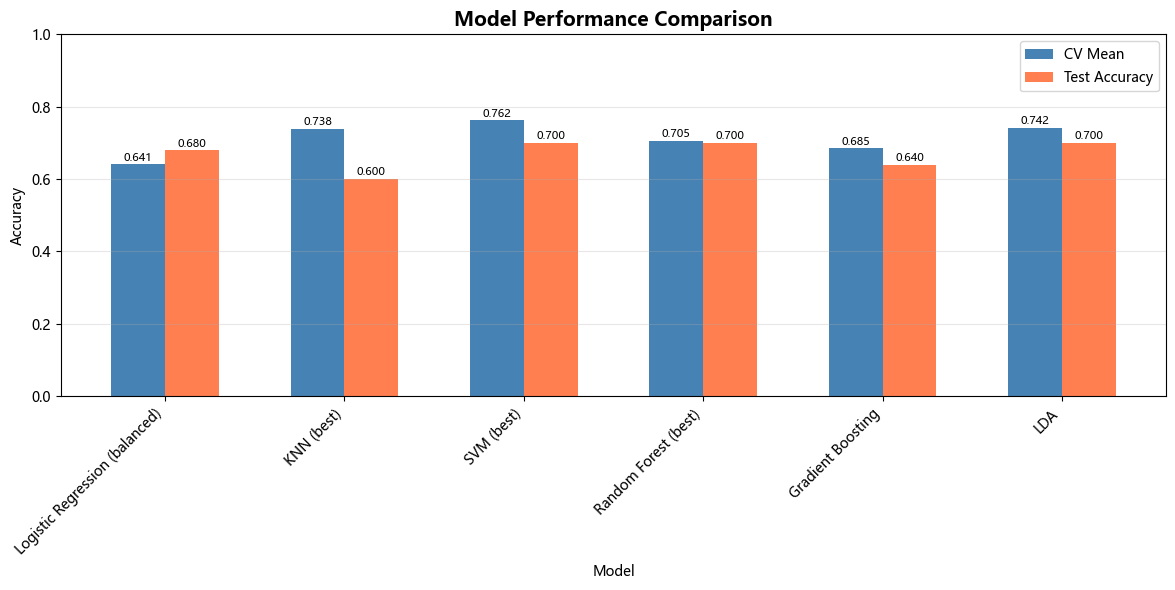

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(final_df)); width = 0.3
bars1 = ax.bar(x - width/2, final_df["CV Mean"], width, label="CV Mean", color="steelblue")
bars2 = ax.bar(x + width/2, final_df["Test Acc"], width, label="Test Accuracy", color="coral")
ax.set_xlabel("Model"); ax.set_ylabel("Accuracy")
ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(final_df["Model"], rotation=45, ha="right")
ax.legend(); ax.grid(axis="y", alpha=0.3); ax.set_ylim(0, 1.0)
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{bar.get_height():.3f}", ha="center", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{bar.get_height():.3f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

### 7.3 Confusion Matrix (Best SVM)

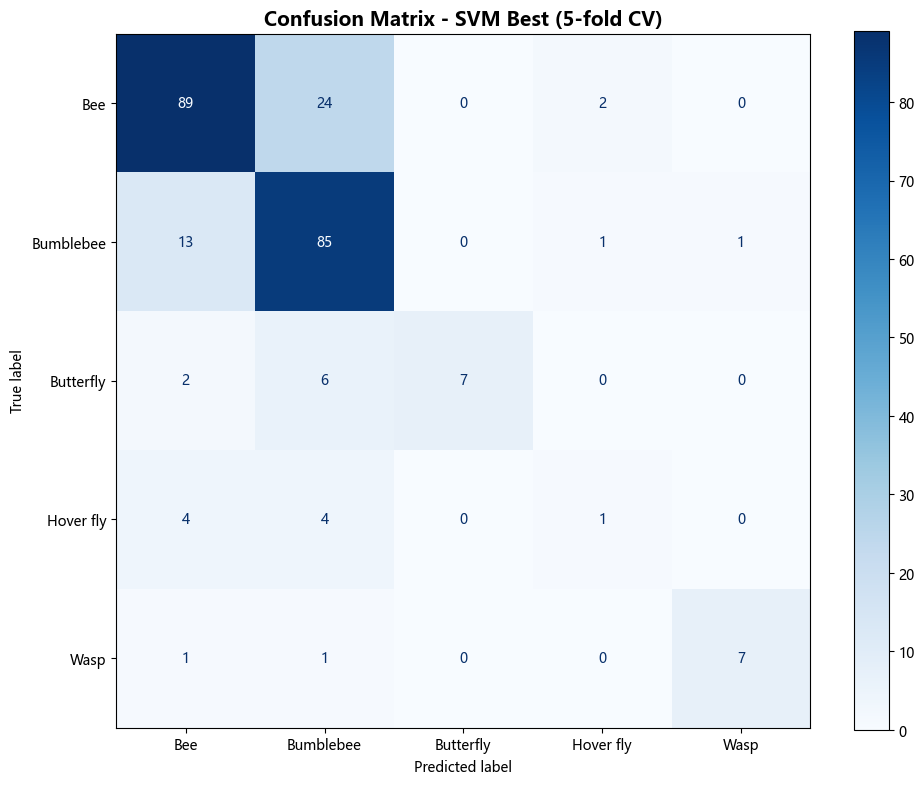


Classification Report (Cross-validated):
              precision    recall  f1-score   support

         Bee       0.82      0.77      0.79       115
   Bumblebee       0.71      0.85      0.77       100
   Butterfly       1.00      0.47      0.64        15
   Hover fly       0.25      0.11      0.15         9
        Wasp       0.88      0.78      0.82         9

    accuracy                           0.76       248
   macro avg       0.73      0.60      0.64       248
weighted avg       0.77      0.76      0.75       248



In [27]:
best_svm = svm_gs.best_estimator_
y_pred_cv = cross_val_predict(best_svm, X_scaled, y_encoded, cv=cv)
cm = confusion_matrix(y_encoded, y_pred_cv)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap="Blues", ax=ax, values_format="d")
ax.set_title("Confusion Matrix - SVM Best (5-fold CV)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

print("\nClassification Report (Cross-validated):")
print(classification_report(y_encoded, y_pred_cv, target_names=le.classes_))

### 7.4 Per-Class Performance

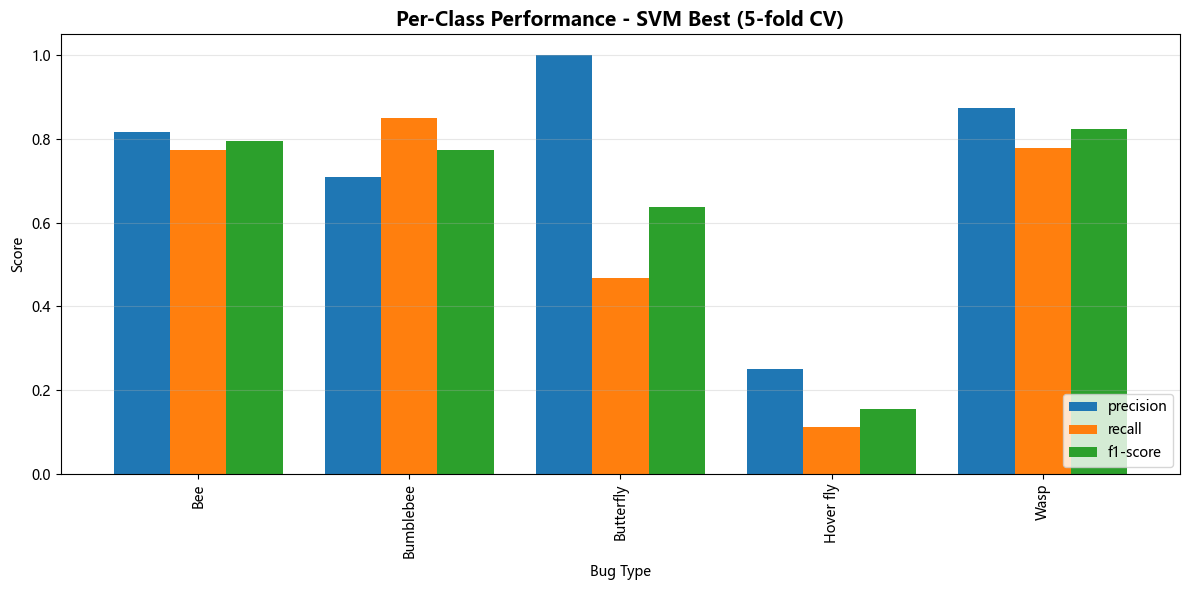

In [28]:
report = classification_report(y_encoded, y_pred_cv, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).transpose()

fig, ax = plt.subplots(figsize=(12, 6))
metrics = report_df.loc[le.classes_, ["precision", "recall", "f1-score"]]
metrics.plot(kind="bar", ax=ax, width=0.8)
ax.set_title("Per-Class Performance - SVM Best (5-fold CV)", fontsize=14, fontweight="bold")
ax.set_ylabel("Score"); ax.set_xlabel("Bug Type")
ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

---

## Part 8: Optional - Neural Network (MLP)

In [29]:
print("=" * 50)
print("Optional: MLP Neural Network")
print("=" * 50)
try:
    mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation="relu", solver="adam",
                        alpha=0.001, batch_size=32, learning_rate="adaptive", max_iter=1000,
                        early_stopping=True, validation_fraction=0.1, random_state=42, verbose=True)
    mlp_scores = cross_val_score(mlp, X_scaled, y_encoded, cv=cv, scoring="accuracy")
    print(f"\nMLP CV Accuracy: {mlp_scores.mean():.4f} +/- {mlp_scores.std():.4f}")
    mlp.fit(X_train, y_train)
    mlp_pred = mlp.predict(X_test)
    mlp_acc = accuracy_score(y_test, mlp_pred)
    print(f"MLP Test Accuracy: {mlp_acc:.4f}")
    print(classification_report(y_test, mlp_pred, target_names=le.classes_, zero_division=0))
    if mlp_acc > final_df.loc[best_idx, "Test Acc"]:
        print(f"\n  MLP is better! Using MLP as final model.")
        best_name = "MLP Neural Network"
except Exception as e:
    print(f"MLP failed: {e}")

Optional: MLP Neural Network
Iteration 1, loss = 1.32274169
Validation score: 0.550000
Iteration 2, loss = 1.02008793
Validation score: 0.550000
Iteration 3, loss = 0.92237318
Validation score: 0.650000
Iteration 4, loss = 0.85854588
Validation score: 0.650000
Iteration 5, loss = 0.79136742
Validation score: 0.650000
Iteration 6, loss = 0.73453070
Validation score: 0.600000
Iteration 7, loss = 0.69420884
Validation score: 0.600000
Iteration 8, loss = 0.65508843
Validation score: 0.600000
Iteration 9, loss = 0.62418425
Validation score: 0.600000
Iteration 10, loss = 0.58963103
Validation score: 0.600000
Iteration 11, loss = 0.56781512
Validation score: 0.600000
Iteration 12, loss = 0.53420717
Validation score: 0.600000
Iteration 13, loss = 0.50794540
Validation score: 0.600000
Iteration 14, loss = 0.48412709
Validation score: 0.600000
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Iteration 1, loss = 1.32289667
Validation score: 0.550000
Ite

---

## Part 9: Save Best Model

In [30]:
print(f"Training final model ({best_name}) on all data...")
if "MLP" in best_name:
    final_model = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation="relu",
                                solver="adam", alpha=0.001, batch_size=32,
                                learning_rate="adaptive", max_iter=1000,
                                early_stopping=True, random_state=42)
else:
    final_model = models[best_name]

final_model.fit(X_scaled, y_encoded)

model_data = {"model": final_model, "scaler": scaler, "label_encoder": le,
              "feature_cols": feature_cols, "model_name": best_name}

model_path = os.path.join(WORK_DIR, "best_model.pkl")
with open(model_path, "wb") as f:
    pickle.dump(model_data, f)

print(f"  Saved to best_model.pkl")
print(f"  Type: {best_name}")
print(f"  Classes: {list(le.classes_)}")

Training final model (SVM (best)) on all data...
  Saved to best_model.pkl
  Type: SVM (best)
  Classes: ['Bee', 'Bumblebee', 'Butterfly', 'Hover fly', 'Wasp']


---

## Part 10: Prediction Pipeline (Test 251-347)

>   Place test images in `test/` directory: `test/251.JPG` ~ `test/347.JPG`

In [31]:
def predict_test_set(test_dir=None, model_path=None, output_path=None):
    if test_dir is None:
        test_dir = os.path.join(WORK_DIR, 'test')
    if model_path is None:
        model_path = os.path.join(WORK_DIR, 'best_model.pkl')
    if output_path is None:
        output_path = os.path.join(WORK_DIR, 'predictions_251_347.csv')
    
    if not os.path.exists(test_dir):
        print(f'Test directory not found: {test_dir}')
        print('Create test/ folder with 251.JPG to 347.JPG')
        return None
    if not os.path.exists(model_path):
        print(f'Model not found: {model_path}')
        return None
    
    print(f'Loading model: {model_path}')
    with open(model_path, 'rb') as f:
        model_data = pickle.load(f)
    model = model_data['model']
    scaler_m = model_data['scaler']
    le_m = model_data['label_encoder']
    feature_cols_m = model_data.get('feature_cols', [])
    print(f'Model: {model_data.get("model_name", "Unknown")}')
    print(f'Classes: {list(le_m.classes_)}')
    
    test_masks_dir = os.path.join(test_dir, 'masks')
    test_images = sorted(glob.glob(os.path.join(test_dir, '*.JPG')))
    if not test_images:
        print(f'No JPG images in {test_dir}')
        return None
    test_ids = []
    for p in test_images:
        try:
            test_ids.append(int(os.path.splitext(os.path.basename(p))[0]))
        except ValueError:
            continue
    test_ids = sorted(test_ids)
    print(f'Found {len(test_ids)} test images ({min(test_ids)}-{max(test_ids)})')
    
    all_features = []
    for img_id in test_ids:
        try:
            masks_dir = test_masks_dir if os.path.exists(test_masks_dir) else MASKS_DIR
            img_rgb, mask = load_image_and_mask(img_id, base_dir=test_dir, masks_dir=masks_dir)
            features = extract_features_for_image(img_id, img_rgb, mask)
            all_features.append(features)
            if img_id % 10 == 0:
                print(f'  Processed {img_id}')
        except Exception as e:
            print(f'  Error on {img_id}: {e}')
    
    if not all_features:
        return None
    features_df = pd.DataFrame(all_features)
    for col in feature_cols_m:
        if col not in features_df.columns:
            features_df[col] = 0
    X_test = features_df[feature_cols_m].values.astype(np.float64)
    X_test_scaled = scaler_m.transform(X_test)
    y_pred_encoded = model.predict(X_test_scaled)
    y_pred_labels = le_m.inverse_transform(y_pred_encoded)
    output_df = pd.DataFrame({'ID': features_df['ID'], 'bug type': y_pred_labels})
    output_df.to_csv(output_path, index=False)
    
    print(f'\nSaved to: {output_path}')
    print(f'\nPrediction Distribution:')
    dist = output_df['bug type'].value_counts()
    max_c = dist.max()
    for label, count in dist.items():
        bar = chr(9608) * int(count / max_c * 40)
        print(f'  {label:15s} | {bar} {count}')
    return output_df

print('Prediction pipeline ready!')
print('Run predict_test_set() when test images are available.')

Prediction pipeline ready!
Run predict_test_set() when test images are available.


---
## Part 11: Requirement Completion and Final Model Improvements

<!-- NOTEBOOK_COMPLETION_MARKER -->

This section was added after re-reading the project PDF. It keeps the original notebook workflow,
then completes the final-model part with:

- corrected cross-validation using sklearn `Pipeline` objects;
- engineered features on top of the original 39 base features;
- class imbalance strategies;
- model fusion with SVM + LDA + ExtraTrees;
- XGBoost / LightGBM / CatBoost comparison;
- final model export and an engineered-feature prediction function for images 251-347.


### 11.1 Requirements Cross-Check

| Requirement from PDF | Notebook Status |
|---|---|
| Color and shape symmetry features | Covered in Part 3 |
| Bug pixel ratio | Covered in Part 3 |
| RGB min/max/mean/median/std inside mask | Covered in Part 3 |
| At least two additional features | Covered by shape, texture, background, saturation, edge features |
| Bug type/species distribution plots | Covered in Part 2 |
| PCA 2D projection | Covered in Part 4 |
| At least two nonlinear projections | Covered by t-SNE and UMAP in Part 4 |
| Two supervised non-ensemble methods | Logistic Regression, KNN, SVM, LDA |
| One ensemble method | Random Forest, Gradient Boosting, ExtraTrees, Voting |
| At least two clustering methods | KMeans and DBSCAN |
| Optional deep learning | MLPClassifier |
| Quality metrics and comments | CV accuracy, holdout accuracy, clustering scores, classification reports |
| Final CSV for 251-347 | Function provided; requires `test/` images and masks |


### 11.2 Corrected Validation Protocol

The earlier baseline cells scale `X_scaled` before cross-validation. For the final model comparison,
scaling is placed inside model pipelines so each fold learns scaling parameters only from its own
training split. This avoids mild data leakage and gives a more reliable estimate.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight

try:
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    from catboost import CatBoostClassifier
    BOOSTING_AVAILABLE = True
except Exception as e:
    BOOSTING_AVAILABLE = False
    print(f"Boosting libraries not available: {e}")

print("Final-model utilities loaded.")


### 11.3 Engineered Features

The project already has all required base features. The final model uses additional derived features
that combine existing color, shape, symmetry, and texture variables. These do not require the raw
images again; they are calculated from `features.csv`.


In [ ]:
def safe_ratio(a, b, eps=1e-9):
    return a / (b + eps)

def add_engineered_features_local(input_df):
    out = input_df.copy()
    added = []

    def add(name, value):
        out[name] = value
        added.append(name)

    rgb_means = out[["r_mean", "g_mean", "b_mean"]]
    rgb_medians = out[["r_median", "g_median", "b_median"]]
    rgb_stds = out[["r_std", "g_std", "b_std"]]
    rgb_maxs = out[["r_max", "g_max", "b_max"]]
    rgb_mins = out[["r_min", "g_min", "b_min"]]

    add("r_range", out["r_max"] - out["r_min"])
    add("g_range", out["g_max"] - out["g_min"])
    add("b_range", out["b_max"] - out["b_min"])
    add("mean_channel_spread", rgb_means.max(axis=1) - rgb_means.min(axis=1))
    add("median_channel_spread", rgb_medians.max(axis=1) - rgb_medians.min(axis=1))
    add("range_channel_spread", rgb_maxs.max(axis=1) - rgb_mins.min(axis=1))
    add("mean_color_std", rgb_stds.mean(axis=1))
    add("max_color_std", rgb_stds.max(axis=1))

    add("rg_mean_diff", out["r_mean"] - out["g_mean"])
    add("rb_mean_diff", out["r_mean"] - out["b_mean"])
    add("gb_mean_diff", out["g_mean"] - out["b_mean"])
    add("rg_mean_ratio", safe_ratio(out["r_mean"], out["g_mean"]))
    add("rb_mean_ratio", safe_ratio(out["r_mean"], out["b_mean"]))
    add("gb_mean_ratio", safe_ratio(out["g_mean"], out["b_mean"]))
    add("red_cv", safe_ratio(out["r_std"], out["r_mean"]))
    add("green_cv", safe_ratio(out["g_std"], out["g_mean"]))
    add("blue_cv", safe_ratio(out["b_std"], out["b_mean"]))

    add("yellow_score", (out["r_mean"] + out["g_mean"]) / 2.0 - out["b_mean"])
    add("warmth_score", out["r_mean"] - out["b_mean"])
    add("darkness_score", 255.0 - out["brightness_mean"])
    add("saturation_brightness_ratio", safe_ratio(out["saturation_mean"], out["brightness_mean"]))
    add("bug_bg_brightness_diff", out["brightness_mean"] - out["bg_brightness"])
    add("bug_bg_brightness_absdiff", (out["brightness_mean"] - out["bg_brightness"]).abs())

    add("symmetry_mean", (out["sym_h"] + out["sym_v"]) / 2.0)
    add("symmetry_product", out["sym_h"] * out["sym_v"])
    add("symmetry_absdiff", (out["sym_h"] - out["sym_v"]).abs())
    add("aspect_log", np.log1p(out["sym_aspect"].clip(lower=0)))
    add("area_sqrt", np.sqrt(out["area"].clip(lower=0)))
    add("perimeter_area_ratio", safe_ratio(out["perimeter"], np.sqrt(out["area"].clip(lower=0))))
    add("convex_area_ratio", safe_ratio(out["convex_area"], out["area"]))
    add("solidity_extent_product", out["solidity"] * out["extent"])
    add("eccentricity_aspect_product", out["eccentricity"] * out["sym_aspect"])

    hu_cols = [f"hu{i}" for i in range(1, 8)]
    hu_abs = out[hu_cols].abs()
    add("hu_abs_sum", hu_abs.sum(axis=1))
    add("hu_abs_mean", hu_abs.mean(axis=1))
    add("hu_abs_std", hu_abs.std(axis=1))
    add("hu_energy", (out[hu_cols] ** 2).sum(axis=1))

    add("edge_texture_product", out["edge_density"] * out["texture_contrast"])
    add("edge_pixel_product", out["edge_density"] * out["pixel_ratio"])
    add("texture_brightness_ratio", safe_ratio(out["texture_contrast"], out["brightness_mean"]))
    add("texture_saturation_ratio", safe_ratio(out["texture_contrast"], out["saturation_mean"]))
    add("color_texture_product", out["color_dominance"] * out["texture_contrast"])

    numeric_cols = [c for c in out.columns if c not in ["ID", "bug type", "species"]]
    out[numeric_cols] = out[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return out, added

engineered_df, engineered_added = add_engineered_features_local(df_filtered)
engineered_feature_cols = [c for c in engineered_df.columns if c not in ["ID", "bug type", "species"]]
engineered_df.to_csv(os.path.join(WORK_DIR, "features_engineered.csv"), index=False)

print(f"Base features: {len(feature_cols)}")
print(f"Engineered features added: {len(engineered_added)}")
print(f"Final engineered feature count: {len(engineered_feature_cols)}")
print(engineered_added)


### 11.4 Reproducible Final Experiments

The full sweeps are stored as scripts so this notebook stays readable:

- `improved_modeling.py`: corrected pipeline validation and engineered-feature comparison.
- `advanced_modeling.py`: imbalance strategies, model fusion, and sklearn ensemble models.
- `boosting_experiments.py`: XGBoost, LightGBM, and CatBoost comparison.

The cell below loads existing results if present; otherwise it runs the scripts.


In [ ]:
import runpy

for script, result_file in [
    ("improved_modeling.py", "improved_modeling_results.csv"),
    ("advanced_modeling.py", "advanced_modeling_results.csv"),
    ("boosting_experiments.py", "boosting_model_results.csv"),
]:
    if not os.path.exists(os.path.join(WORK_DIR, result_file)):
        print(f"Running {script}...")
        runpy.run_path(os.path.join(WORK_DIR, script), run_name="__main__")
    else:
        print(f"Found {result_file}; loading saved results.")

result_paths = {
    "improved": os.path.join(WORK_DIR, "improved_modeling_results.csv"),
    "advanced": os.path.join(WORK_DIR, "advanced_modeling_results.csv"),
    "boosting": os.path.join(WORK_DIR, "boosting_model_results.csv"),
}

if os.path.exists(result_paths["improved"]):
    improved_results = pd.read_csv(result_paths["improved"])
    display(improved_results.head(8))
else:
    print("improved_modeling_results.csv not present; run improved_modeling.py to regenerate it if needed.")

advanced_results = pd.read_csv(result_paths["advanced"])
boosting_results = pd.read_csv(result_paths["boosting"])
display(advanced_results.head(10))
display(boosting_results.head(8))


### 11.5b Enhanced Visualizations

<!-- ENHANCED_VISUALS_MARKER -->

The first plots were sufficient for the project requirements. The following enhanced plots make the
final report easier to read:

- annotated class imbalance and top species counts;
- PCA/t-SNE/UMAP in one comparable panel using the 80 engineered features;
- final voting-model confusion matrix, both counts and per-class recall;
- model comparison across sklearn/fusion and boosted-tree methods;
- feature importance from the ExtraTrees component of the final voting model;
- boxplots of interpretable engineered features by class.


In [ ]:
if os.path.exists(os.path.join(WORK_DIR, "enhanced_visualizations.py")):
    runpy.run_path(os.path.join(WORK_DIR, "enhanced_visualizations.py"), run_name="__main__")
else:
    print("enhanced_visualizations.py not found.")


In [ ]:
enhanced_figures = [
    "fig_class_balance_enhanced.png",
    "fig_embedding_panel_enhanced.png",
    "fig_final_model_confusion_enhanced.png",
    "fig_model_comparison_enhanced.png",
    "fig_feature_importance_enhanced.png",
    "fig_feature_boxplots_enhanced.png",
]

for fig_path in enhanced_figures:
    full_path = os.path.join(WORK_DIR, fig_path)
    if os.path.exists(full_path):
        display(Image.open(full_path))
    else:
        print(f"Missing: {fig_path}")


### 11.6 Results Summary and Final Choice

The improved experiments were run after correcting validation leakage and using the 80-feature engineered table.

Top final candidates:

| Model | Imbalance Strategy | CV Accuracy Mean | CV Macro F1 Mean | Holdout Accuracy |
| --- | --- | --- | --- | --- |
| Voting SVM+LDA+ET | none | 0.8024 | 0.5979 | 0.7600 |
| SVM RBF tuned gamma=0.01 | none | 0.7744 | 0.5876 | 0.7200 |
| SVM RBF C=10 | none | 0.7702 | 0.5783 | 0.7000 |
| LDA shrinkage | none | 0.7660 | 0.6071 | 0.7200 |
| SVM RBF C=10 balanced | none | 0.7660 | 0.5630 | 0.7400 |
| ExtraTrees balanced | none | 0.7540 | 0.5019 | 0.6800 |
| Voting SVM+LDA+ET | hybrid_50 | 0.7500 | 0.6037 | 0.7400 |
| Random Forest balanced | none | 0.7456 | 0.5112 | 0.7000 |

Additional boosted-tree comparison:

| Model | Family | Imbalance Strategy | CV Accuracy Mean | CV Macro F1 Mean | Holdout Accuracy |
| --- | --- | --- | --- | --- | --- |
| CatBoost compact | catboost | balanced_weight | 0.7620 | 0.6158 | 0.6400 |
| XGBoost conservative | xgboost | none | 0.7537 | 0.5069 | 0.7000 |
| LightGBM shallow | lightgbm | balanced_weight | 0.7458 | 0.5473 | 0.6800 |
| CatBoost compact | catboost | none | 0.7457 | 0.4387 | 0.7000 |
| LightGBM shallow | lightgbm | none | 0.7456 | 0.5190 | 0.7000 |
| XGBoost deeper | xgboost | none | 0.7456 | 0.4735 | 0.7200 |

**Final selected model:** `Voting SVM+LDA+ET` with `none` resampling.

- CV accuracy: `0.8024 +/- 0.0462`
- CV macro F1: `0.5979`
- Holdout accuracy: `0.7600`

The best XGBoost/LightGBM/CatBoost result was `CatBoost compact` with
`balanced_weight`. Its CV accuracy was `0.7620`,
so it did not beat the final soft-voting ensemble.


### 11.6b Repeated CV and Minority-Class Strategy

<!-- REPEATED_CV_MINORITY_MARKER -->

Because the dataset is small and imbalanced, a single 5-fold split can be misleading. This section
uses `RepeatedStratifiedKFold(n_splits=5, n_repeats=10)`, giving 50 validation folds, and compares:

- the current soft-voting model;
- SVM and LDA baselines;
- resampled `hybrid_50` variants;
- two-stage classifiers: first `Bee/Bumblebee` vs `Other`, then specialist classifiers.


In [ ]:
if os.path.exists(os.path.join(WORK_DIR, "repeated_minority_experiments.py")):
    if not os.path.exists(os.path.join(WORK_DIR, "repeated_cv_results.csv")):
        runpy.run_path(os.path.join(WORK_DIR, "repeated_minority_experiments.py"), run_name="__main__")
    else:
        print("Found repeated_cv_results.csv; loading saved repeated-CV results.")
else:
    print("repeated_minority_experiments.py not found.")

repeated_results = pd.read_csv(os.path.join(WORK_DIR, "repeated_cv_results.csv"))
repeated_per_class = pd.read_csv(os.path.join(WORK_DIR, "repeated_cv_per_class_results.csv"))

display(repeated_results)
display(
    repeated_per_class[
        repeated_per_class["Model"].isin([
            "Voting SVM+LDA+ET",
            "Voting SVM+LDA+ET hybrid_50",
            "Two-stage SVM/SVM/SVM",
        ])
    ].round(4)
)


Repeated 5x10 CV summary:

| Model | Family | Fit Strategy | CV Accuracy Mean | CV Accuracy Std | CV Macro F1 Mean | CV Macro F1 Std | CV Balanced Acc Mean |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Voting SVM+LDA+ET | fusion | none | 0.7928 | 0.0421 | 0.5989 | 0.0898 | 0.5899 |
| SVM RBF C=10 | svm | none | 0.7670 | 0.0441 | 0.5759 | 0.0817 | 0.5694 |
| SVM RBF C=10 balanced | svm_weighted | none | 0.7578 | 0.0517 | 0.5647 | 0.0843 | 0.5671 |
| Voting SVM+LDA+ET hybrid_50 | fusion_resampled | hybrid_50 | 0.7481 | 0.0527 | 0.6020 | 0.0962 | 0.6284 |
| LDA shrinkage | linear | none | 0.7481 | 0.0538 | 0.5813 | 0.1052 | 0.6014 |
| Two-stage LDA/LDA/LDA | two_stage | none | 0.7291 | 0.0519 | 0.5095 | 0.0913 | 0.5085 |
| Two-stage SVM/SVM/LDA | two_stage | none | 0.7158 | 0.0565 | 0.5552 | 0.0804 | 0.5917 |
| Two-stage SVM/SVM/SVM | two_stage | none | 0.7150 | 0.0579 | 0.5579 | 0.0819 | 0.5877 |
| SVM RBF C=10 hybrid_50 | svm_resampled | hybrid_50 | 0.7130 | 0.0641 | 0.5644 | 0.0853 | 0.5886 |

**Accuracy winner:** `Voting SVM+LDA+ET` with `none`.

- CV accuracy: `0.7928 +/- 0.0421`
- CV macro F1: `0.5989`

**Macro-F1 winner:** `Voting SVM+LDA+ET hybrid_50` with `hybrid_50`.

- CV accuracy: `0.7481`
- CV macro F1: `0.6020 +/- 0.0962`

The macro-F1 winner only improves macro F1 slightly, while losing substantial accuracy. Therefore,
the original soft-voting model remains the best choice when the leaderboard metric is plain accuracy.


### 11.7 Train and Save the Final Selected Model

The final model is a soft-voting ensemble:

- SVM RBF: nonlinear decision boundary;
- shrinkage LDA: stable linear discriminant for small datasets;
- ExtraTrees: ensemble model for nonlinear feature interactions.

This model is saved as `best_model_engineered.pkl` and should be used for the hidden test set if
the final metric is plain accuracy.


In [ ]:
final_X = engineered_df[engineered_feature_cols].values.astype(np.float64)
final_y = engineered_df["bug type"].values

svm_prob = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42)),
])
lda_shrinkage = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
])
extra_trees = ExtraTreesClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=1,
)

final_voting_model = VotingClassifier(
    estimators=[
        ("svm", svm_prob),
        ("lda", lda_shrinkage),
        ("et", extra_trees),
    ],
    voting="soft",
)
final_voting_model.fit(final_X, final_y)

final_payload = {
    "model": final_voting_model,
    "model_name": "Voting SVM+LDA+ExtraTrees",
    "feature_cols": engineered_feature_cols,
    "base_feature_cols": feature_cols,
    "engineered_feature_cols": engineered_added,
    "rare_classes_removed": ["Dragonfly", "Bee & Bumblebee"],
    "target_col": "bug type",
    "label_mode": "string_labels",
    "notes": "Extract base features, call add_engineered_features_local, select feature_cols, then predict.",
}

final_model_path = os.path.join(WORK_DIR, "best_model_engineered.pkl")
with open(final_model_path, "wb") as f:
    pickle.dump(final_payload, f)

train_pred = final_voting_model.predict(final_X)
print(f"Saved final model to: {final_model_path}")
print(pd.Series(train_pred).value_counts())


### 11.8 Engineered-Feature Prediction Function for Test Images 251-347

When the hidden test images and masks are placed in `test/`, run `predict_test_set_engineered()`.
It writes the required two-column CSV: `ID, bug type`.


In [ ]:
def predict_test_set_engineered(test_dir=None, model_path=None, output_path=None):
    if test_dir is None:
        test_dir = os.path.join(WORK_DIR, "test")
    if model_path is None:
        model_path = os.path.join(WORK_DIR, "best_model_engineered.pkl")
    if output_path is None:
        output_path = os.path.join(WORK_DIR, "predictions_251_347.csv")

    if not os.path.exists(test_dir):
        print(f"Test directory not found: {test_dir}")
        print("Place test images as test/251.JPG ... test/347.JPG, with masks in test/masks/ if available.")
        return None
    if not os.path.exists(model_path):
        print(f"Final model not found: {model_path}")
        return None

    with open(model_path, "rb") as f:
        payload = pickle.load(f)

    model = payload["model"]
    final_cols = payload["feature_cols"]

    test_images = sorted(glob.glob(os.path.join(test_dir, "*.JPG")))
    test_ids = []
    for path in test_images:
        try:
            test_ids.append(int(os.path.splitext(os.path.basename(path))[0]))
        except ValueError:
            pass
    test_ids = sorted(test_ids)
    if not test_ids:
        print(f"No numeric JPG images found in {test_dir}")
        return None

    test_masks_dir = os.path.join(test_dir, "masks")
    all_features = []
    for img_id in test_ids:
        try:
            masks_dir = test_masks_dir if os.path.exists(test_masks_dir) else MASKS_DIR
            img_rgb, mask = load_image_and_mask(img_id, base_dir=test_dir, masks_dir=masks_dir)
            feats = extract_features_for_image(img_id, img_rgb, mask)
            all_features.append(feats)
            if img_id % 10 == 0:
                print(f"Processed {img_id}")
        except Exception as e:
            print(f"Error on {img_id}: {e}")

    if not all_features:
        print("No test features extracted.")
        return None

    test_base = pd.DataFrame(all_features)
    test_engineered, _ = add_engineered_features_local(test_base)
    for col in final_cols:
        if col not in test_engineered.columns:
            test_engineered[col] = 0.0
    X_final_test = test_engineered[final_cols].values.astype(np.float64)
    pred = model.predict(X_final_test)

    output_df = pd.DataFrame({"ID": test_engineered["ID"].astype(int), "bug type": pred})
    output_df = output_df.sort_values("ID")
    output_df.to_csv(output_path, index=False)
    print(f"Saved predictions to: {output_path}")
    print(output_df["bug type"].value_counts())
    return output_df

print("Engineered prediction function ready.")


### 11.9 Generate Final PDF Report

The project deliverable asks for a PDF report. The script below creates `final_project_report.pdf`
from the notebook outputs, figures, and final experiment tables.


In [ ]:
if os.path.exists(os.path.join(WORK_DIR, "generate_final_report.py")):
    runpy.run_path(os.path.join(WORK_DIR, "generate_final_report.py"), run_name="__main__")
else:
    print("generate_final_report.py not found.")


---
## Final Deliverables Checklist

| Required Item | Status |
|---|---|
| Feature Extraction | Done: 39 base features plus 41 engineered features |
| Distribution Visualization | Done: bug type and species plots |
| PCA Projection | Done |
| Two Nonlinear Projections | Done: t-SNE and UMAP |
| Two Supervised Non-Ensemble Models | Done: Logistic Regression, KNN, SVM, LDA |
| Supervised Ensemble Model | Done: Random Forest, Gradient Boosting, ExtraTrees, Voting |
| Two Clustering Methods | Done: KMeans and DBSCAN |
| Optional Deep Learning | Done: MLPClassifier |
| Hyperparameter / Model Selection | Done: grid search, corrected CV, boosted-tree comparison |
| Class Imbalance Handling | Done: class weights, oversampling, hybrid resampling, undersampling |
| Final Saved Model | Done: `best_model_engineered.pkl` |
| PDF Report | Done: `final_project_report.pdf` |
| CSV for Images 251-347 | Ready: run `predict_test_set_engineered()` after `test/` images are provided |

**Important limitation:** the hidden test images 251-347 are not currently present in this workspace,
so the final prediction CSV cannot be generated until those files are added.


## Part 12: Feature Selection Check

This optional improvement checks whether the engineered feature space can be simplified without losing much generalization performance. I compare the full 80-feature model against variance filtering, correlation filtering, univariate SelectKBest, ExtraTrees model-based selection, and RFE with balanced logistic regression. All comparisons use repeated stratified cross-validation with 5 folds and 10 repeats, and macro F1 is tracked because several insect classes are small.

The full feature set remains the best choice for maximum repeated-CV accuracy. The RFE 40-feature model is a compact alternative: it removes half of the engineered features while staying very close in accuracy and slightly improving repeated-CV macro F1. Because the holdout set is small and minority-class metrics are noisy, the final 80-feature voting model is still kept as the primary submission model.


In [ ]:
import json
from pathlib import Path
import pandas as pd

feature_selection_results_path = Path("feature_selection_results.csv")
selected_features_path = Path("selected_features.csv")
feature_selection_summary_path = Path("feature_selection_summary.json")

if not feature_selection_results_path.exists():
    raise FileNotFoundError("Run feature_selection_experiments.py first to generate feature-selection outputs.")

fs_results = pd.read_csv(feature_selection_results_path)
fs_results = fs_results.sort_values(["CV Accuracy Mean", "CV Macro F1 Mean"], ascending=[False, False])
display_cols = [
    "Selection",
    "Selected Feature Count Mean",
    "CV Accuracy Mean",
    "CV Accuracy Std",
    "CV Macro F1 Mean",
    "Holdout Accuracy",
    "Holdout Macro F1",
]
display(fs_results[display_cols].head(12).round(4))


In [ ]:
with feature_selection_summary_path.open("r", encoding="utf-8") as f:
    feature_selection_summary = json.load(f)

selected_features = pd.read_csv(selected_features_path)["feature"].tolist()
print("Accuracy winner:", feature_selection_summary["accuracy_winner"])
print("Compact alternative:", feature_selection_summary["recommended_compact_selection"])
print("Selected feature count:", len(selected_features))
display(pd.DataFrame({"selected_feature": selected_features}))
